In [10]:
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt
%matplotlib inline
from skimage.feature import local_binary_pattern
import numpy as np
import torch
import torch.nn
os.environ['CUDA_VISIBLE_DEVICES']='2'
import time

In [11]:
real_file = '../data/gan/hospital_6/experiment_registration2/8.2.out/train_result/intermidiate_result_train_cta_to_dwi_bxxx_hospital6_lbploss_20200519/epoch_220_index_8_dst_real_4455178_first_FU_DWI_BXXX.nii.gz'

fake_file = '../data/gan/hospital_6/experiment_registration2/8.2.out/train_result/intermidiate_result_train_cta_to_dwi_bxxx_hospital6_lbploss_20200519/epoch_220_index_8_dst_fake_4455178_first_FU_DWI_BXXX.nii.gz'

print(os.path.isfile(real_file))
print(os.path.isfile(fake_file))

True
True


In [12]:
real_img = sitk.ReadImage(real_file)
fake_img = sitk.ReadImage(fake_file)
real_arr = sitk.GetArrayFromImage(real_img)
fake_arr = sitk.GetArrayFromImage(fake_img)

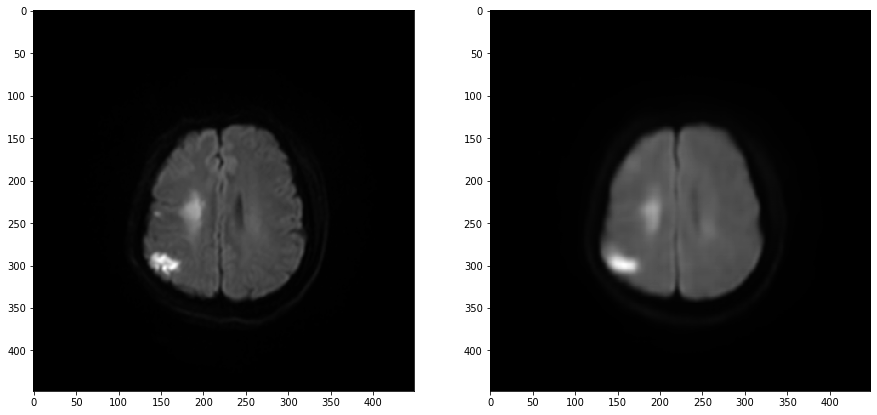

In [13]:
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.imshow(real_arr[0], cmap='gray')
plt.subplot(1,2,2)
plt.imshow(fake_arr[0], cmap='gray')

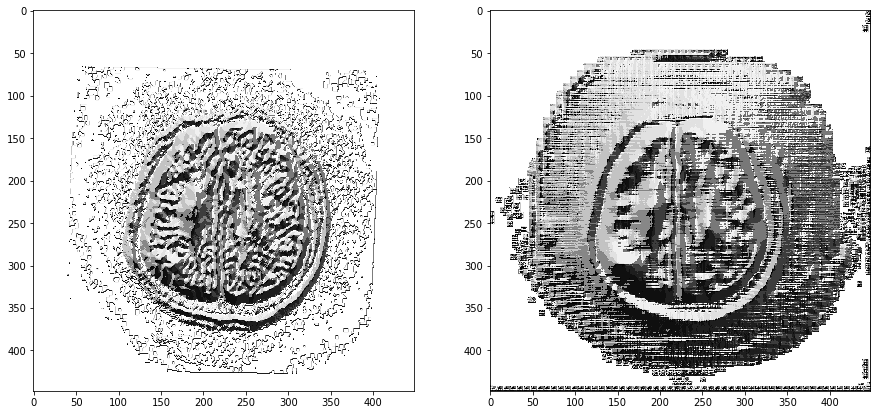

In [14]:
# 计算2d lbp

# settings for LBP
radius = 1  # LBP算法中范围半径的取值
n_points = 8 * radius # 领域像素点数

real_lbp = local_binary_pattern(real_arr[0], n_points, radius)
fake_lbp = local_binary_pattern(fake_arr[0], n_points, radius)

plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.imshow(real_lbp, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(fake_lbp, cmap='gray')

In [6]:
# 画出整图的lbp loss

real_lbp = np.zeros(real_arr.shape)
fake_lbp = np.zeros(fake_arr.shape)

plt.figure(figsize=(15,225))

d = real_arr.shape[0]
for i in range(d):
    real_lbp[i] = local_binary_pattern(real_arr[i], n_points, radius)
    fake_lbp[i] = local_binary_pattern(fake_arr[i], n_points, radius)

    # plt.subplot(d,2,i*2+1)
    # plt.imshow(real_lbp[i], cmap='gray')
    # plt.subplot(d,2,i*2+2)
    # plt.imshow(fake_lbp[i], cmap='gray')
    # break

<Figure size 1080x16200 with 0 Axes>

In [7]:
criterionL1 = torch.nn.L1Loss()
real_lbp_tensor = torch.from_numpy(real_lbp)
fake_lbp_tensor = torch.from_numpy(fake_lbp)
criterionL1(real_lbp_tensor, fake_lbp_tensor)

tensor(81.8112, dtype=torch.float64)

In [8]:
for i in range(real_lbp.shape[0]):
    real_lbp_tensor = torch.from_numpy(real_lbp[i])
    fake_lbp_tensor = torch.from_numpy(fake_lbp[i])
    l1_loss = criterionL1(real_lbp_tensor, fake_lbp_tensor)
    print(l1_loss)


tensor(80.4508, dtype=torch.float64)
tensor(79.9357, dtype=torch.float64)
tensor(79.1785, dtype=torch.float64)
tensor(79.5088, dtype=torch.float64)
tensor(79.3884, dtype=torch.float64)
tensor(78.6190, dtype=torch.float64)
tensor(78.7499, dtype=torch.float64)
tensor(77.4443, dtype=torch.float64)
tensor(78.1017, dtype=torch.float64)
tensor(78.0560, dtype=torch.float64)
tensor(77.0710, dtype=torch.float64)
tensor(76.9873, dtype=torch.float64)
tensor(77.8177, dtype=torch.float64)
tensor(78.0763, dtype=torch.float64)
tensor(78.2479, dtype=torch.float64)
tensor(77.6761, dtype=torch.float64)
tensor(79.0528, dtype=torch.float64)
tensor(79.7193, dtype=torch.float64)
tensor(79.4403, dtype=torch.float64)
tensor(79.0945, dtype=torch.float64)
tensor(86.8383, dtype=torch.float64)
tensor(85.8496, dtype=torch.float64)
tensor(88.3639, dtype=torch.float64)
tensor(88.1611, dtype=torch.float64)
tensor(88.0445, dtype=torch.float64)
tensor(88.8618, dtype=torch.float64)
tensor(87.9370, dtype=torch.float64)
t

In [59]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from skimage.feature import local_binary_pattern

class LBPLoss(nn.Module):
    def __init__(self, radius=1, n_points=8):
        super(LBPLoss, self).__init__()
        self.radius = radius
        self.n_points = n_points

    def forward(self, input, target):
        '''
        input: gpu variable tensor, (n,c,d,h,w)
        target: cpu tensor, (n,c,d,h,w)
        '''
        # flat
        input = input.detach().cpu().numpy() # n,c,d,h,w
        input = np.reshape(input, [-1, input.shape[-1]])
        target = target.detach().cpu().numpy()
        target = np.reshape(target, [-1, input.shape[-1]])
        lbp_input = local_binary_pattern(input, self.n_points, self.radius)
        lbp_target = local_binary_pattern(target, self.n_points, self.radius)
        loss = torch.nn.L1Loss()(torch.from_numpy(lbp_input), torch.from_numpy(lbp_target))
        return loss

class MaskLBPLoss(nn.Module):
    def __init__(self, radius=1, n_points=8):
        super(MaskLBPLoss, self).__init__()
        self.radius = radius
        self.n_points = n_points

    def forward(self, input, target, mask):
        '''
        input: gpu variable tensor, (n,c,d,h,w)
        target: cpu tensor, (n,c,d,h,w)
        mask: numpy arr, (n,c,d,h,w)
        '''
        # flat
        input = input.detach().cpu().numpy() # n,c,d,h,w
        input = np.reshape(input, [-1, input.shape[-1]])
        target = target.detach().cpu().numpy()
        target = np.reshape(target, [-1, input.shape[-1]])
        mask = np.reshape(mask, [-1, input.shape[-1]])
        input = input*mask
        target = target*mask
        lbp_input = local_binary_pattern(input, self.n_points, self.radius)
        lbp_target = local_binary_pattern(target, self.n_points, self.radius)
        loss = torch.nn.L1Loss()(torch.from_numpy(lbp_input), torch.from_numpy(lbp_target))
        return loss


In [60]:
lbp_loss = LBPLoss()
input = Variable(torch.from_numpy(fake_arr).unsqueeze(0).unsqueeze(0).cuda())
target = torch.from_numpy(real_arr).cuda()
beg = time.time()
loop_num = 1
for i in range(loop_num):
    loss = lbp_loss(input, target)
    print(loss.dtype)
    print(loss)
end = time.time()
print('total time:{:.3f}\tavg time:{:.3f}'.format(end-beg, (end-beg)/loop_num))

tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
tensor(81.8113, dtype=torch.float64)
total time:79.644	avg time:3.982


In [58]:
lbp_loss = MaskLBPLoss()
input = Variable(torch.from_numpy(fake_arr).unsqueeze(0).unsqueeze(0).cuda())
target = torch.from_numpy(real_arr).cuda()
mask = np.random.randint(0,2,input.shape)
beg = time.time()
loop_num = 20
for i in range(loop_num):
    loss = lbp_loss(input, target,mask)
    print(loss)
end = time.time()
print('total time:{:.3f}\tavg time:{:.3f}'.format(end-beg, (end-beg)/loop_num))


tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
tensor(30.4429, dtype=torch.float64)
total time:75.247	avg time:3.762
